In [1]:
from dotenv import load_dotenv
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from src.logistic_regression import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
import time

In [2]:
sns.set_theme(style="whitegrid")

## Step 1 — Connect to Database

In [3]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = (
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

In [4]:
query = f"SELECT * FROM customer_churn"

df = pd.read_sql(query, engine)
df.head()

,customerID,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2 — EDA

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [7]:
print(df.isnull().sum())

customerID          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [8]:
df["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["churn"].value_counts(normalize=True).mul(100).round(2)

churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

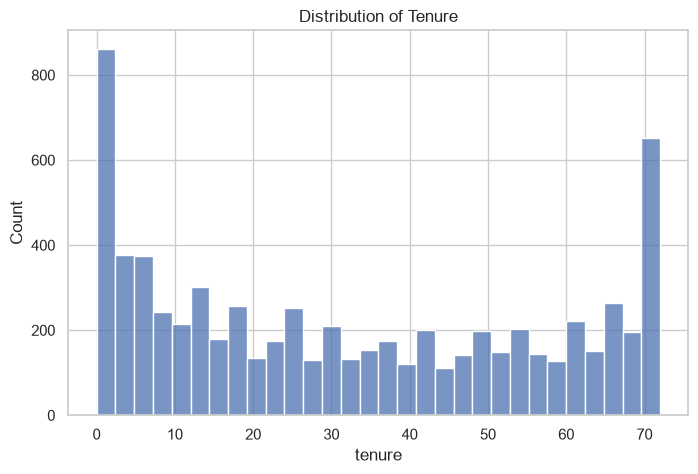

In [10]:
plt.figure(figsize = (8,5))
sns.histplot(df["tenure"], bins = 30)
plt.title("Distribution of Tenure")
plt.show()

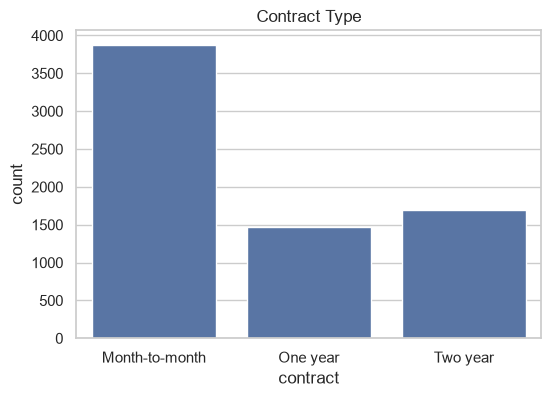

In [11]:
plt.figure(figsize = (6,4))
sns.countplot(data = df, x = "contract")
plt.title("Contract Type")
plt.show()

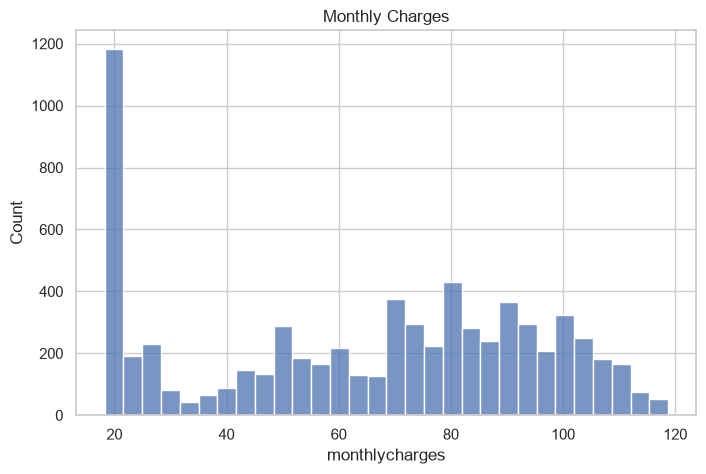

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["monthlycharges"], bins=30)
plt.title("Monthly Charges")
plt.show()

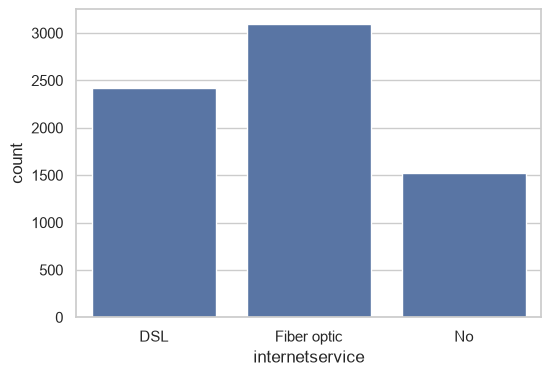

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="internetservice")
plt.show()

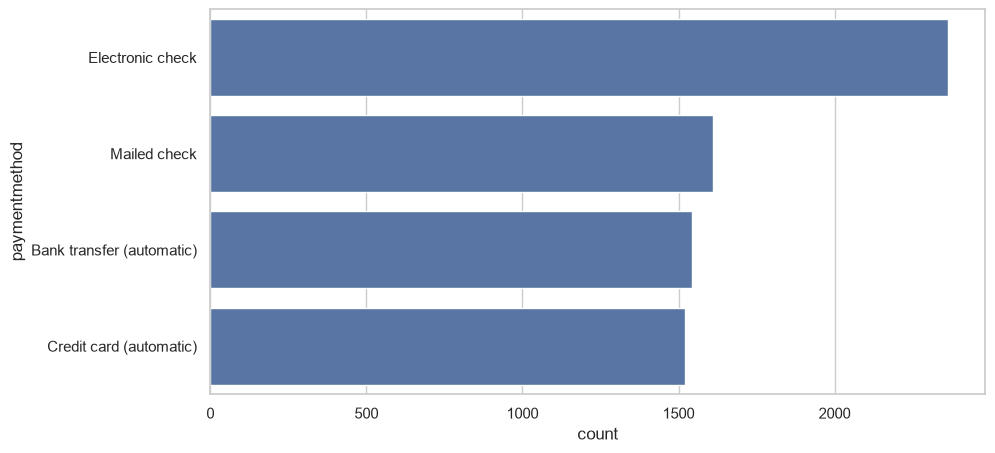

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="paymentmethod")
plt.show()

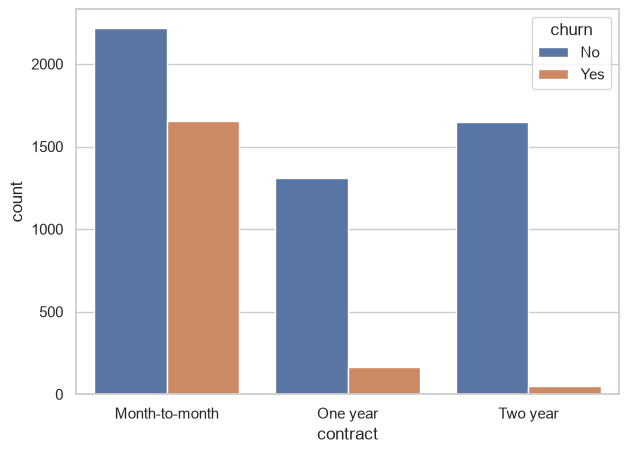

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x="contract",
              hue="churn")
plt.show()

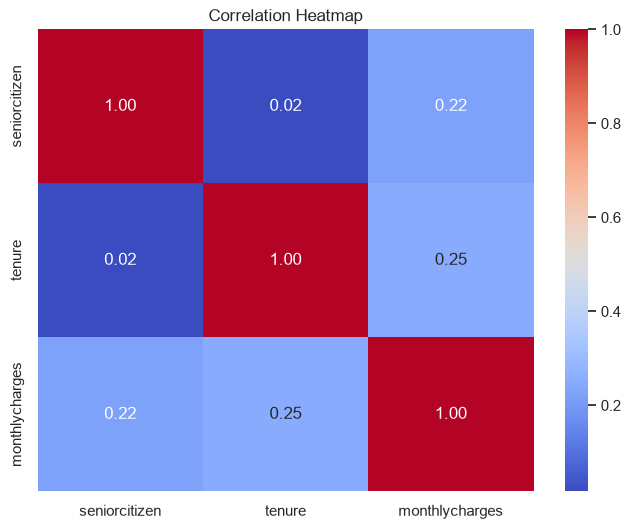

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Step 3 — Preprocessing

In [17]:
df = df.drop(columns=["customerID"])

In [18]:
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors = "coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   str    
 3   dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   str    
 6   multiplelines     7043 non-null   str    
 7   internetservice   7043 non-null   str    
 8   onlinesecurity    7043 non-null   str    
 9   onlinebackup      7043 non-null   str    
 10  deviceprotection  7043 non-null   str    
 11  techsupport       7043 non-null   str    
 12  streamingtv       7043 non-null   str    
 13  streamingmovies   7043 non-null   str    
 14  contract          7043 non-null   str    
 15  paperlessbilling  7043 non-null   str    
 16  paymentmethod     7043 non-null   str    
 17  monthl

In [19]:
df = df.dropna()

In [20]:
X = df.drop("churn", axis = 1)
y = df["churn"]

In [21]:
service_cols = ["onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies"]

for col in service_cols:
    X[col] = X[col].replace("No internet service", "No")

X["multiplelines"] = X["multiplelines"].replace("No phone service", "No")

In [22]:
y = y.map({"No": 0, "Yes": 1})

In [23]:
numeric_features = X.select_dtypes(include = ["int64", "float64"]).columns
categorical_features = X.select_dtypes(include = ["str"]).columns

In [24]:
print(numeric_features)
print(categorical_features)

Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges'], dtype='str')
Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod'],
      dtype='str')


In [25]:
preprocessor = ColumnTransformer(transformers = [
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop = "first", handle_unknown = "ignore"), categorical_features)
])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 19), (1407, 19), (5625,), (1407,))

In [27]:
y_train.value_counts()

churn
0    4130
1    1495
Name: count, dtype: int64

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [75]:
cond_number = np.linalg.cond(X_train_processed)
rank = np.linalg.matrix_rank(X_train_processed)
print(f"Condition number: {cond_number:.2e}")
print(f"Rank: {rank} / {X_train_processed.shape[1]}")

Condition number: 1.49e+01
Rank: 23 / 23


## Step 4 — Manual logistic regression from scratch

In [29]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [30]:
y_train

array([0, 0, 0, ..., 0, 0, 1], shape=(5625,))

In [31]:
weights, bias, loss_history = gradient_descent(X_train_processed, y_train, learning_rate = 0.01, iterations = 1000)

In [32]:
weights

array([ 0.17919948, -0.51856093,  0.52641814, -0.19910129, -0.14206665,
       -0.21904675, -0.195572  , -0.32207133, -0.0222317 ,  0.20767235,
       -0.27832705, -0.25491158, -0.16604764, -0.12581954, -0.23828379,
       -0.00396837, -0.01195832, -0.2421913 , -0.31418036,  0.04434458,
       -0.16583748,  0.18771892, -0.17916457])

In [33]:
bias

np.float64(-0.35870213654756905)

In [34]:
loss_history[:5], loss_history[-5:]

([np.float64(0.6931471805599454),
  np.float64(0.6901654684063265),
  np.float64(0.6872412651823622),
  np.float64(0.6843732929398255),
  np.float64(0.6815602985191813)],
 [np.float64(0.43366762276799675),
  np.float64(0.4336441517997524),
  np.float64(0.43362073148192043),
  np.float64(0.4335973616693388),
  np.float64(0.43357404221735474)])

In [35]:
y_pred = predict(X_test_processed, weights, bias)
acc = accuracy(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.7832


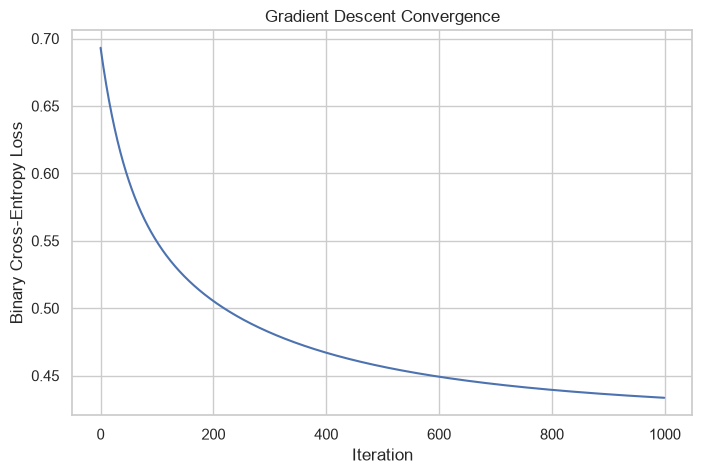

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Gradient Descent Convergence")
plt.savefig("assets/gradient-descent-convergence")
plt.show()

## Step 5 — Validate from-scratch against sklearn

In [37]:
sk_model = LogisticRegression(penalty = None, solver='lbfgs', max_iter = 5000)
sk_model.fit(X_train_processed, y_train)

C:\Users\zahin\miniconda3\envs\cv-mle\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.T

In [38]:
sk_weights = sk_model.coef_.flatten()
sk_bias = sk_model.intercept_[0]

print('sklearn weight shape:', sk_weights.shape)
print('sklearn bias:', sk_bias)

sklearn weight shape: (23,)
sklearn bias: -4.105528811299717


In [39]:
feature_names = preprocessor.get_feature_names_out()

coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Scratch': weights,
    'Sklearn': sk_weights
})

coef_comparison['Absolute_Difference'] = (coef_comparison['Scratch'] - coef_comparison['Sklearn']).abs()
coef_comparison.head(10)

,Feature,Scratch,Sklearn,Absolute_Difference
0,num__seniorcitizen,0.179199,0.085037,0.094162
1,num__tenure,-0.518561,-1.430360,0.911799
2,num__monthlycharges,0.526418,-2.242488,2.768906
3,num__totalcharges,-0.199101,0.694834,0.893935
4,cat__gender_Male,-0.142067,-0.025613,0.116454
5,cat__partner_Yes,-0.219047,-0.028265,0.190782
6,cat__dependents_Yes,-0.195572,-0.158835,0.036737
7,cat__phoneservice_Yes,-0.322071,0.790232,1.112304
8,cat__multiplelines_Yes,-0.022232,0.644346,0.666578
9,cat__internetservice_Fiber optic,0.207672,2.689287,2.481614


In [40]:
coef_comparison.sort_values('Absolute_Difference', ascending = False).head()

,Feature,Scratch,Sklearn,Absolute_Difference
2,num__monthlycharges,0.526418,-2.242488,2.768906
9,cat__internetservice_Fiber optic,0.207672,2.689287,2.481614
10,cat__internetservice_No,-0.278327,-2.582391,2.304064
7,cat__phoneservice_Yes,-0.322071,0.790232,1.112304
18,cat__contract_Two year,-0.314180,-1.378502,1.064322


In [41]:
scratch_prob = predict_proba(X_test_processed, weights, bias)
sk_prob = sk_model.predict_proba(X_test_processed)[:, 1]

In [42]:
prob_comparison = pd.DataFrame({
    'Actual': y_test[:10],
    'Scratch_Prob': np.round(scratch_prob[:10], 4),
    'Sklearn_Prob': np.round(sk_prob[:10], 4)
})

prob_comparison

,Actual,Scratch_Prob,Sklearn_Prob
0,0,0.0694,0.0161
1,0,0.5584,0.6039
2,0,0.0649,0.0041
3,1,0.2396,0.1914
4,0,0.1256,0.0916
5,1,0.2946,0.4467
6,0,0.0772,0.0261
7,0,0.0269,0.0018
8,1,0.3554,0.4090
9,0,0.0609,0.0137


In [43]:
scratch_pred = predict(X_test_processed, weights, bias)
sk_pred = sk_model.predict(X_test_processed)

In [44]:
scratch_acc = accuracy(y_test, scratch_pred)
sk_acc = sk_model.score(X_test_processed, y_test)

print(f'Scratch Accuracy : {scratch_acc:.4f}')
print(f'Sklearn Accuracy : {sk_acc:.4f}')

Scratch Accuracy : 0.7832
Sklearn Accuracy : 0.7974


In [45]:
comparison_summary = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Bias Term', 'Coefficient Vector Size'],
    'Scratch': [round(scratch_acc, 4), round(float(bias), 4), len(weights)],
    'Sklearn': [round(sk_acc, 4), round(float(sk_bias), 4), len(sk_weights)]
})

comparison_summary

,Metric,Scratch,Sklearn
0,Test Accuracy,0.7832,0.7974
1,Bias Term,-0.3587,-4.1055
2,Coefficient Vector Size,23.0000,23.0000


In [46]:
coef_mae = np.mean(np.abs(weights - sk_weights))
coef_corr = np.corrcoef(weights, sk_weights)[0, 1]

print(f'Coefficient MAE: {coef_mae:.6f}')
print(f'Coefficient Correlation: {coef_corr:.6f}')

Coefficient MAE: 0.758135
Coefficient Correlation: 0.190097


## Step 6 — The three-way bake-off For Logistic Regression, KNN, and SVM (RBF kernel)

### Logistic Regression

In [47]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_params = {"C": [0.01, 0.1, 1, 10, 100]}

lr_grid = GridSearchCV(estimator = LogisticRegression(max_iter = 5000), param_grid = lr_params, 
                       cv = cv, scoring = "f1", n_jobs = -1)

In [48]:
start = time.perf_counter()

lr_grid.fit(X_train_processed, y_train)

lr_train_time = time.perf_counter() - start

In [49]:
lr_model = lr_grid.best_estimator_
print(lr_grid.best_params_)

{'C': 100}


### KNN

In [50]:
knn_params = {"n_neighbors": list(range(3, 26, 2))}

knn_grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid=knn_params, cv = cv, scoring="f1", n_jobs = -1)

In [51]:
start = time.perf_counter()

knn_grid.fit(X_train_processed, y_train)

knn_train_time = time.perf_counter() - start

In [52]:
knn_model = knn_grid.best_estimator_
print(knn_grid.best_params_)

{'n_neighbors': 25}


### SVM (RBF)

In [53]:
svm_params = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.1, 0.01, 0.001]}

svm_grid = GridSearchCV(estimator = SVC(kernel = "rbf", probability = True), param_grid = svm_params,
                        cv = cv, scoring = "f1", n_jobs = -1)

In [54]:
start = time.perf_counter()

svm_grid.fit(X_train_processed, y_train)

svm_train_time = time.perf_counter() - start

C:\Users\zahin\miniconda3\envs\cv-mle\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [55]:
svm_model = svm_grid.best_estimator_
print(svm_grid.best_params_)

{'C': 10, 'gamma': 0.001}


### Evaluation

In [56]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [57]:
lr_results = evaluate_model(lr_model, X_test_processed, y_test)
knn_results = evaluate_model(knn_model, X_test_processed, y_test)
svm_results = evaluate_model(svm_model, X_test_processed, y_test)

In [58]:
comparison = pd.DataFrame({

    "Model": ["Logistic Regression", "KNN", "SVM (RBF)"],
    
    "Accuracy": [
        lr_results["Accuracy"],
        knn_results["Accuracy"],
        svm_results["Accuracy"]
    ],

    "Precision": [
        lr_results["Precision"],
        knn_results["Precision"],
        svm_results["Precision"]
    ],

    "Recall": [
        lr_results["Recall"],
        knn_results["Recall"],
        svm_results["Recall"]
    ],

    "F1": [
        lr_results["F1"],
        knn_results["F1"],
        svm_results["F1"]
    ],

    "ROC-AUC": [
        lr_results["ROC-AUC"],
        knn_results["ROC-AUC"],
        svm_results["ROC-AUC"]
    ],

    "Training Time (s)": [
        lr_train_time,
        knn_train_time,
        svm_train_time
    ]

})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.7982,0.6398,0.5508,0.5920,0.8325,3.7327
1,KNN,0.7939,0.6214,0.5749,0.5972,0.8236,0.7836
2,SVM (RBF),0.7953,0.6414,0.5214,0.5752,0.8228,56.1429


## Step 7 — Evaluation & the imbalance discussion

## Confusion Matrix

In [59]:
def plot_confusion_matrix(model, X_test, y_test, title):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Churn", "Churn"])

    disp.plot(cmap = "Blues")
    plt.title(title)
    plt.show()

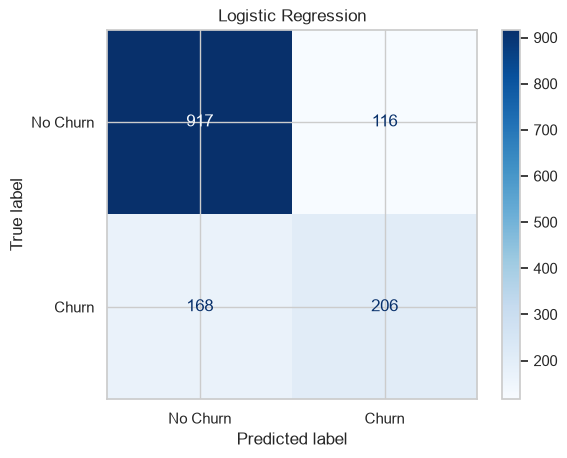

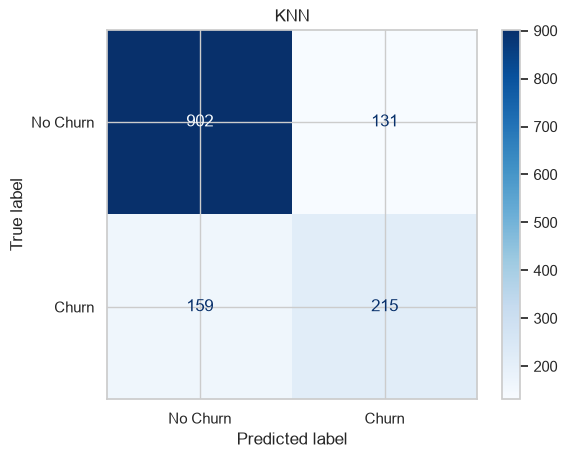

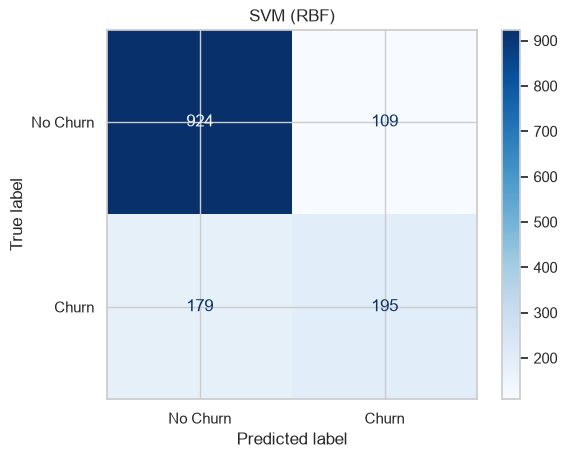

In [60]:
plot_confusion_matrix(lr_model, X_test_processed, y_test, "Logistic Regression")
plot_confusion_matrix(knn_model, X_test_processed, y_test, "KNN")
plot_confusion_matrix(svm_model, X_test_processed, y_test, "SVM (RBF)")

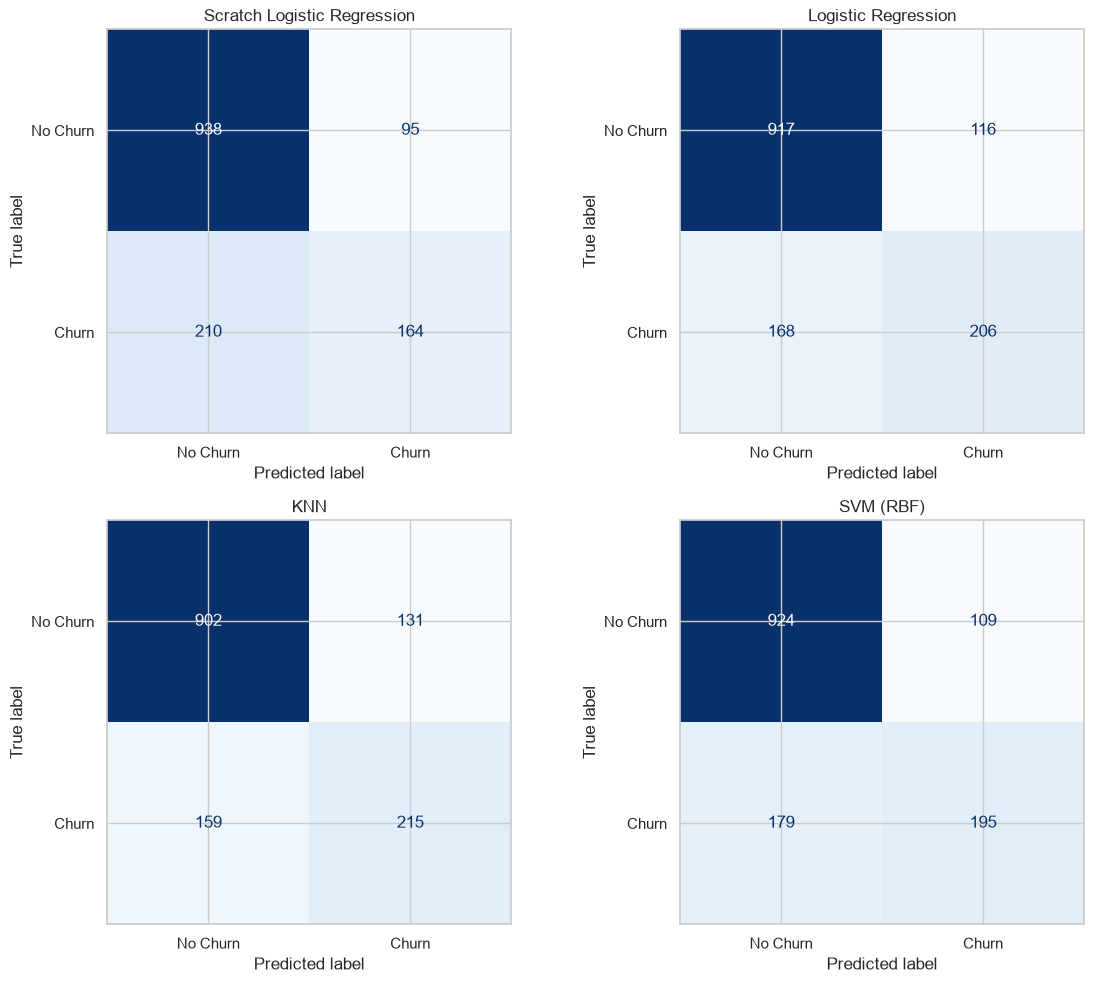

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [("Scratch Logistic Regression", None), 
          ("Logistic Regression", lr_model),
          ("KNN", knn_model),
          ("SVM (RBF)", svm_model)]


for ax, (title, model) in zip(axes.ravel(), models):

    if title == "Scratch Logistic Regression":
        y_pred = predict(X_test_processed, weights, bias)
    else:
        y_pred = model.predict(X_test_processed)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Churn", "Churn"])
    disp.plot(ax = ax, cmap = "Blues", colorbar = False)
    ax.set_title(title)


plt.tight_layout()
plt.savefig("assets/confusion_matrices.png", bbox_inches = "tight")
plt.show()

### Precision / Recall / F1 Per Class

In [62]:
print(classification_report(y_test, lr_model.predict(X_test_processed), target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [63]:
print(classification_report(y_test, knn_model.predict(X_test_processed), target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.87      0.86      1033
       Churn       0.62      0.57      0.60       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [64]:
print(classification_report(y_test, svm_model.predict(X_test_processed), target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.64      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



### ROC Curves

In [65]:
lr_prob = lr_model.predict_proba(X_test_processed)[:, 1]
knn_prob = knn_model.predict_proba(X_test_processed)[:, 1]
svm_prob = svm_model.predict_proba(X_test_processed)[:, 1]

In [66]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

In [67]:
lr_auc = roc_auc_score(y_test, lr_prob)
knn_auc = roc_auc_score(y_test, knn_prob)
svm_auc = roc_auc_score(y_test, svm_prob)

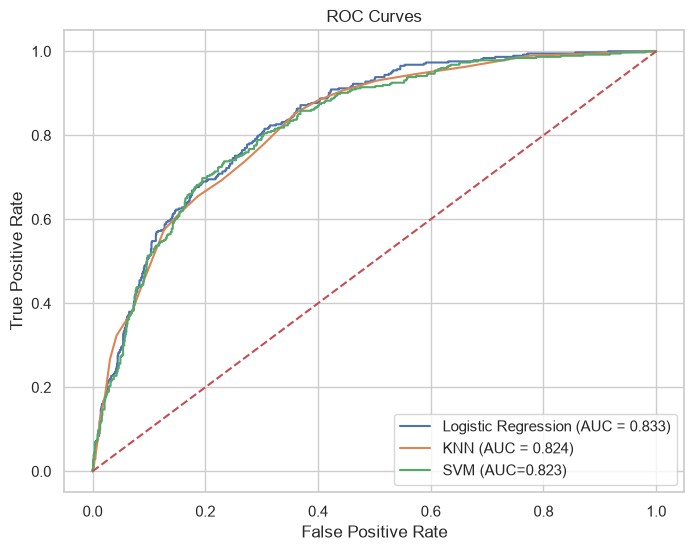

In [68]:
plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label = f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(knn_fpr, knn_tpr, label = f"KNN (AUC = {knn_auc:.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC={svm_auc:.3f})")

plt.plot([0,1], [0,1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("assets/roc-curves.png")
plt.show()

### Compare Recall of the Churn Class

In [69]:
comparison = {"Logistic Regression": recall_score(y_test, lr_model.predict(X_test_processed)),
              "KNN": recall_score(y_test, knn_model.predict(X_test_processed)),
              "SVM": recall_score(y_test, svm_model.predict(X_test_processed))}

print(comparison)

{'Logistic Regression': 0.5508021390374331, 'KNN': 0.5748663101604278, 'SVM': 0.5213903743315508}


### Precision–Recall Curve

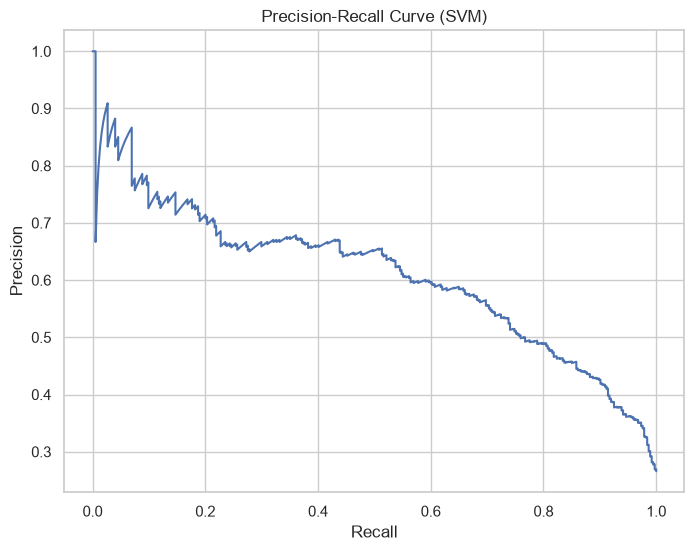

In [70]:
precision, recall, thresholds = precision_recall_curve(y_test, svm_prob)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.savefig("assets/precision-recall-curve-svm")
plt.show()

### Threshold Experiment

In [71]:
threshold = 0.30

y_pred = (svm_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred, target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1033
       Churn       0.56      0.69      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.78      0.78      1407



In [72]:
threshold = 0.70

y_pred = (svm_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred, target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.78      0.95      0.86      1033
       Churn       0.66      0.25      0.37       374

    accuracy                           0.77      1407
   macro avg       0.72      0.60      0.61      1407
weighted avg       0.75      0.77      0.73      1407

